In [13]:
from dotenv import load_dotenv
import os
import numpy as np
import torch
from sklearn.model_selection import train_test_split
load_dotenv('.env')
mnist_train_fp = os.getenv('MNIST_TRAIN_FILEPATH')
mnist_test_fp = os.getenv('MNIST_TEST_FILEPATH')
mnist_train = np.load(mnist_train_fp)
mnist_test = np.load(mnist_test_fp)
print(f"Train dataset file path: {mnist_train_fp}")
print(f"Test dataset file path: {mnist_test_fp}")

Train dataset file path: C:\Users\NICKY\Documents\Universidad\Q3 2026\Redes neuronales\Lab2\mnist_dataset\mnist_train.npz
Test dataset file path: C:\Users\NICKY\Documents\Universidad\Q3 2026\Redes neuronales\Lab2\mnist_dataset\mnist_test.npz


In [14]:
SEED = 50
torch.manual_seed(SEED)

X = mnist_train['images']
Y = mnist_train['labels']
X_test = mnist_test['images']
Y_test = mnist_test['labels']


#Aplanar la imagen
X = X.reshape(X.shape[0], -1)
X_test = X_test.reshape(X_test.shape[0], -1)

#escalar a [0,1]
X = X.astype(np.float32) / 255.0
X_test = X_test.astype(np.float32) / 255.0

X_train, X_val, Y_train, Y_val = train_test_split(
    X, Y, test_size=0.2, random_state=SEED, stratify=Y)

In [15]:
X_train_tensor = torch.from_numpy(X_train).float()
Y_train_tensor = torch.from_numpy(Y_train).long()
X_val_tensor = torch.from_numpy(X_val).float()
Y_val_tensor = torch.from_numpy(Y_val).long()
X_test_tensor = torch.from_numpy(X_test).float()
Y_test_tensor = torch.from_numpy(Y_test).long()

In [16]:
from torch.utils.data import DataLoader, TensorDataset

train_dataset = TensorDataset(X_train_tensor, Y_train_tensor)
val_dataset = TensorDataset(X_val_tensor, Y_val_tensor)
test_dataset = TensorDataset(X_test_tensor, Y_test_tensor)

BATCH_SIZE = 64
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

In [17]:
import torch.nn as nn
import torch.nn.functional as F

class DenseNet(nn.Module):
    def __init__ (self):
        super(DenseNet, self).__init__()
        self.layer1 = nn.Linear(784, 128)
        self.layer2 = nn.Linear(128, 10)
    def forward(self, x):
        output = F.relu(self.layer1(x))
        output = self.layer2(output)
        return output


In [18]:
import torch.optim as optim

model = DenseNet()
loss_function = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [19]:
import time

epoch_count = 10

train_loss_history: list[float] = []
val_loss_history: list[float] = []

start_time = time.perf_counter()
for epoch in range(epoch_count):
    model.train()

    train_running_loss = 0.0
    for x_batch, y_batch in train_loader:
        optimizer.zero_grad()
        preds = model(x_batch)
        loss = loss_function(preds, y_batch)

        loss.backward()
        optimizer.step()
        train_running_loss += loss.item()

    val_running_loss = 0.0
    model.eval()
    for x_batch, y_batch in val_loader:
        with torch.no_grad():
            preds = model(x_batch)
            loss = loss_function(preds, y_batch)
            val_running_loss += loss.item()

    train_epoch_loss = train_running_loss / len(train_loader)
    val_epoch_loss = val_running_loss / len(val_loader)
    train_loss_history.append(train_epoch_loss)
    val_loss_history.append(val_epoch_loss)
    print(f"Epoch: {epoch+1}. Train Loss: {train_epoch_loss:.4f}, Eval Loss: {val_epoch_loss:.4f}")

end_time = time.perf_counter()
execution_time = end_time - start_time
print(f"Execution time: {execution_time:.8f} seconds")

Epoch: 1. Train Loss: 0.3808, Eval Loss: 0.2212
Epoch: 2. Train Loss: 0.1780, Eval Loss: 0.1573
Epoch: 3. Train Loss: 0.1256, Eval Loss: 0.1287
Epoch: 4. Train Loss: 0.0949, Eval Loss: 0.1219
Epoch: 5. Train Loss: 0.0746, Eval Loss: 0.1221
Epoch: 6. Train Loss: 0.0595, Eval Loss: 0.1075
Epoch: 7. Train Loss: 0.0486, Eval Loss: 0.1032
Epoch: 8. Train Loss: 0.0397, Eval Loss: 0.1026
Epoch: 9. Train Loss: 0.0329, Eval Loss: 0.0959
Epoch: 10. Train Loss: 0.0269, Eval Loss: 0.0910
Execution time: 53.58399470 seconds


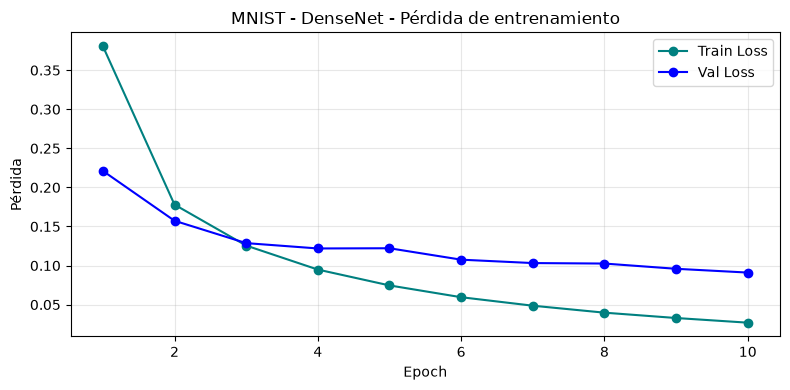

In [20]:
import matplotlib.pyplot as plt

epochs = range(1, epoch_count + 1)

plt.figure(figsize=(8, 4))
plt.plot(epochs, train_loss_history, marker="o", color="teal", label="Train Loss")
plt.plot(epochs, val_loss_history, marker="o", color="blue", label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Pérdida")
plt.title("MNIST - DenseNet - Pérdida de entrenamiento")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [21]:
model.eval()
with torch.no_grad():
    preds = model(X_test_tensor)
    loss = loss_function(preds, Y_test_tensor).item()
    predicted_classes = torch.argmax(preds, dim=1)
    accuracy = (predicted_classes == Y_test_tensor).float().mean().item()

print(f"Loss of the model: {loss:.4f}")
print(f"Accuracy of the model: {accuracy:.4f}")

Loss of the model: 0.0846
Accuracy of the model: 0.9761


In [22]:
mnist_accuracy = accuracy
mnist_test_loss = loss
print(f"Referencia guardada - MNIST Dense Accuracy: {mnist_accuracy:.4f}")


Referencia guardada - MNIST Dense Accuracy: 0.9761


In [ ]:
#PARTE 2
fmnist_train_fp = os.getenv('FMNIST_TRAIN_FILEPATH')
fmnist_test_fp = os.getenv('FMNIST_TEST_FILEPATH')
fmnist_train = np.load(fmnist_train_fp)
fmnist_test = np.load(fmnist_test_fp)
print(f"Train dataset file path: {fmnist_train_fp}")
print(f"Test dataset file path: {fmnist_test_fp}")


Train dataset file path: C:\Users\NICKY\Documents\Universidad\Q3 2026\Redes neuronales\Lab2\fmnist_dataset\fmnist_train.npz
Test dataset file path: C:\Users\NICKY\Documents\Universidad\Q3 2026\Redes neuronales\Lab2\fmnist_dataset\fmnist_test.npz


In [ ]:
X = fmnist_train["images"]
Y = fmnist_train["labels"]
X_test = fmnist_test["images"]
Y_test = fmnist_test["labels"]

X = X.reshape(X.shape[0], -1)
X_test = X_test.reshape(X_test.shape[0], -1)

X = X.astype(np.float32) / 255.0
X_test = X_test.astype(np.float32) / 255.0

X_train, X_val, Y_train, Y_val = train_test_split(
    X, Y, test_size=0.2, random_state=SEED, stratify=Y
)


In [25]:
X_train_tensor = torch.from_numpy(X_train).float()
Y_train_tensor = torch.from_numpy(Y_train).long()
X_val_tensor = torch.from_numpy(X_val).float()
Y_val_tensor = torch.from_numpy(Y_val).long()
X_test_tensor = torch.from_numpy(X_test).float()
Y_test_tensor = torch.from_numpy(Y_test).long()


In [26]:
train_dataset = TensorDataset(X_train_tensor, Y_train_tensor)
val_dataset = TensorDataset(X_val_tensor, Y_val_tensor)
test_dataset = TensorDataset(X_test_tensor, Y_test_tensor)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

In [27]:
model = DenseNet()
loss_function = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [28]:
train_loss_history: list[float] = []
val_loss_history: list[float] = []

start_time = time.perf_counter()
for epoch in range(epoch_count):
    model.train()

    train_running_loss = 0.0
    for x_batch, y_batch in train_loader:
        optimizer.zero_grad()
        preds = model(x_batch)
        loss = loss_function(preds, y_batch)

        loss.backward()
        optimizer.step()
        train_running_loss += loss.item()

    val_running_loss = 0.0
    model.eval()
    for x_batch, y_batch in val_loader:
        with torch.no_grad():
            preds = model(x_batch)
            loss = loss_function(preds, y_batch)
            val_running_loss += loss.item()

    train_epoch_loss = train_running_loss / len(train_loader)
    val_epoch_loss = val_running_loss / len(val_loader)
    train_loss_history.append(train_epoch_loss)
    val_loss_history.append(val_epoch_loss)
    print(f"Epoch: {epoch+1}. Train Loss: {train_epoch_loss:.4f}, Eval Loss: {val_epoch_loss:.4f}")

end_time = time.perf_counter()
execution_time = end_time - start_time
print(f"Execution time: {execution_time:.8f} seconds")


Epoch: 1. Train Loss: 0.5689, Eval Loss: 0.4338
Epoch: 2. Train Loss: 0.4181, Eval Loss: 0.3889
Epoch: 3. Train Loss: 0.3764, Eval Loss: 0.3737
Epoch: 4. Train Loss: 0.3474, Eval Loss: 0.3475
Epoch: 5. Train Loss: 0.3247, Eval Loss: 0.3440
Epoch: 6. Train Loss: 0.3089, Eval Loss: 0.3261
Epoch: 7. Train Loss: 0.2925, Eval Loss: 0.3300
Epoch: 8. Train Loss: 0.2827, Eval Loss: 0.3176
Epoch: 9. Train Loss: 0.2715, Eval Loss: 0.3267
Epoch: 10. Train Loss: 0.2623, Eval Loss: 0.3392
Execution time: 49.88405800 seconds


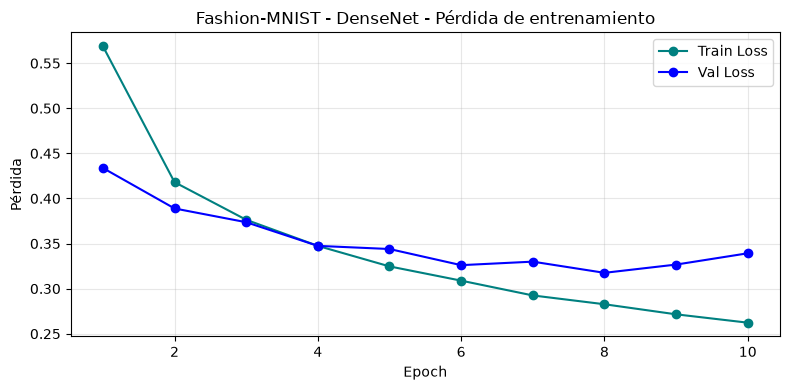

In [29]:
epochs = range(1, epoch_count + 1)

plt.figure(figsize=(8, 4))
plt.plot(epochs, train_loss_history, marker="o", color="teal", label="Train Loss")
plt.plot(epochs, val_loss_history, marker="o", color="blue", label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Pérdida")
plt.title("Fashion-MNIST - DenseNet - Pérdida de entrenamiento")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


In [30]:
model.eval()
with torch.no_grad():
    preds = model(X_test_tensor)
    loss = loss_function(preds, Y_test_tensor).item()
    predicted_classes = torch.argmax(preds, dim=1)
    accuracy = (predicted_classes == Y_test_tensor).float().mean().item()

fmnist_accuracy = accuracy
fmnist_test_loss = loss

print(f"Loss of the model: {loss:.4f}")
print(f"Accuracy of the model: {accuracy:.4f}")


Loss of the model: 0.3763
Accuracy of the model: 0.8686


In [31]:
print(f"{'Dataset':<25}{'Precisión de Prueba':>22}")
print(f"{'MNIST (Parte 1)':<25}{mnist_accuracy:>22.4f}")
print(f"{'Fashion-MNIST (Parte 2)':<25}{fmnist_accuracy:>22.4f}")


Dataset                     Precisión de Prueba
MNIST (Parte 1)                          0.9761
Fashion-MNIST (Parte 2)                  0.8686
